# Mental Health Score Prediction & Recommendation System

An end-to-end machine learning project that predicts a student's **Mental Health Score** from lifestyle and social media usage patterns, classifies their risk level, and generates personalized recommendations.

**Workflow:** Data Understanding → Cleaning → EDA → Feature Engineering → Preprocessing Pipeline → Model Training → Hyperparameter Tuning → Evaluation → Risk Classification → Recommendation Engine → Model Deployment (Pipeline export)

**Target Variable:** `Mental_Health_Score`
**Final Model:** Random Forest Regressor (compared against Linear Regression as a baseline)

## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

In [2]:
DATA_PATH = "Student Social Media And Mental Health Impact.csv"
TARGET = "Mental_Health_Score"

df = pd.read_csv(DATA_PATH)
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


## 3. Basic Dataset Information

In [3]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.info()

Rows: 5000, Columns: 13
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9

In [4]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [5]:
df.columns.tolist()

['Age',
 'Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Stress_Level',
 'Mental_Health_Score']

## 4. Missing Value Analysis

In [6]:
def show_missing_values(data):
    missing_count = data.isnull().sum()
    missing_percent = (missing_count / len(data)) * 100
    summary = pd.DataFrame({"Missing Count": missing_count, "Missing %": missing_percent})
    return summary[summary["Missing Count"] > 0].sort_values("Missing %", ascending=False)


missing_summary = show_missing_values(df)
missing_summary if not missing_summary.empty else "No missing values found"


'No missing values found'

## 5. Duplicate Checking

In [7]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows found: 2
Shape after removing duplicates: (4998, 13)


## 6. Exploratory Data Analysis (EDA)

We explore the distribution of the target variable and how it relates to key lifestyle features.

### 6.1 Target Variable Distribution

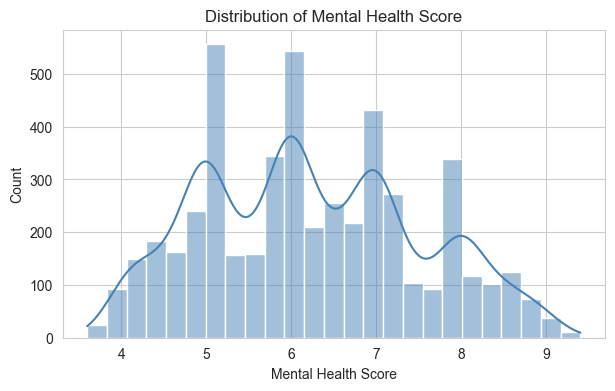

In [8]:
plt.figure(figsize=(7, 4))
sns.histplot(df[TARGET], kde=True, color="steelblue")
plt.title("Distribution of Mental Health Score")
plt.xlabel("Mental Health Score")
plt.show()

### 6.2 Correlation Heatmap

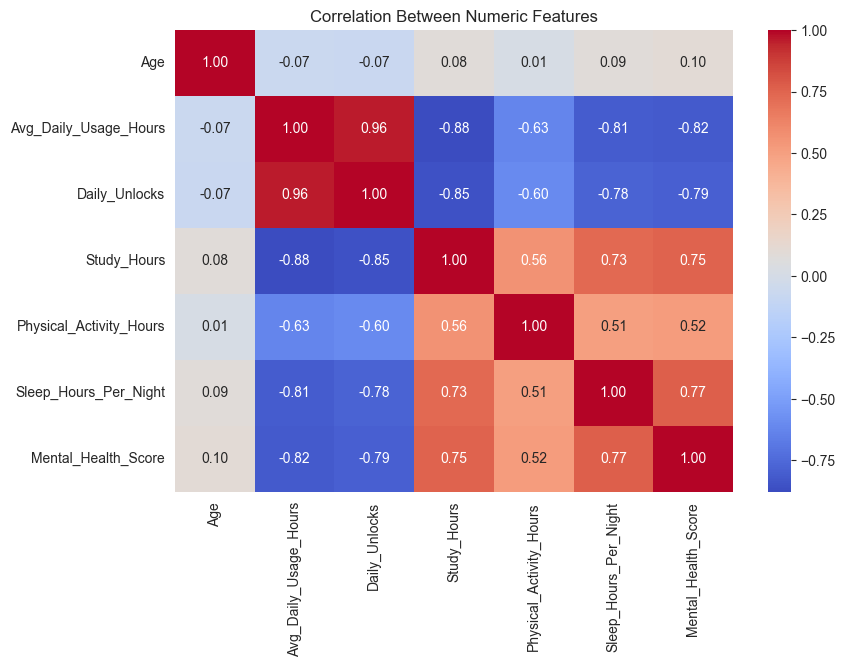

In [9]:
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Between Numeric Features")
plt.show()

### 6.3 Stress Level vs Mental Health Score

C:\Users\Malik Umair\AppData\Local\Temp\ipykernel_16220\945676811.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Stress_Level", y=TARGET, data=df, order=stress_order, palette="Blues")


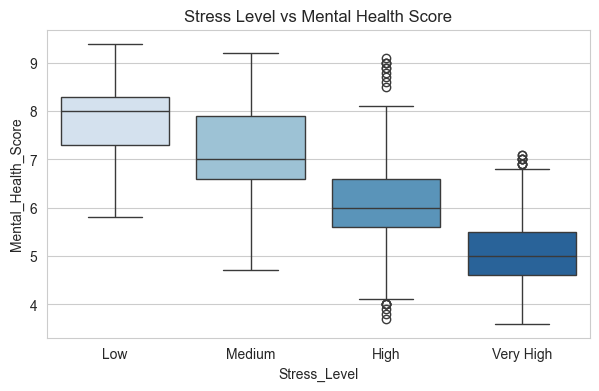

In [10]:
stress_order = ["Low", "Medium", "High", "Very High"]

plt.figure(figsize=(7, 4))
sns.boxplot(x="Stress_Level", y=TARGET, data=df, order=stress_order, palette="Blues")
plt.title("Stress Level vs Mental Health Score")
plt.show()

### 6.4 Daily Usage Hours vs Mental Health Score

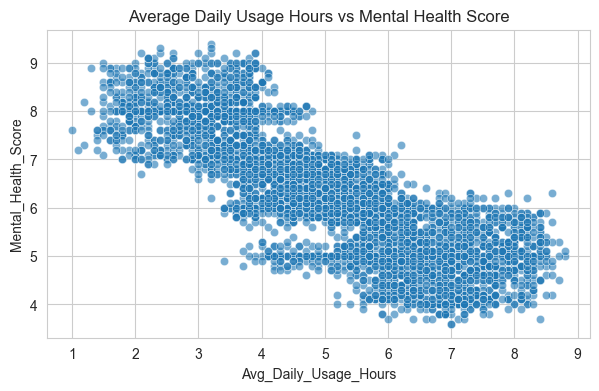

In [11]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x="Avg_Daily_Usage_Hours", y=TARGET, data=df, alpha=0.6)
plt.title("Average Daily Usage Hours vs Mental Health Score")
plt.show()

### 6.5 Sleep Hours vs Mental Health Score

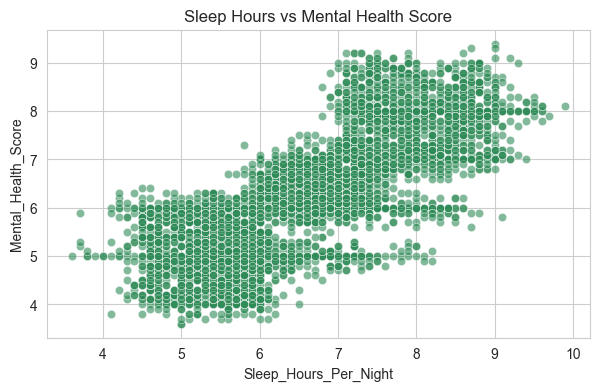

In [12]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x="Sleep_Hours_Per_Night", y=TARGET, data=df, alpha=0.6, color="seagreen")
plt.title("Sleep Hours vs Mental Health Score")
plt.show()

### 6.6 Most Used Platform

C:\Users\Malik Umair\AppData\Local\Temp\ipykernel_16220\569551471.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Most_Used_Platform", data=df, order=platform_order, palette="viridis")


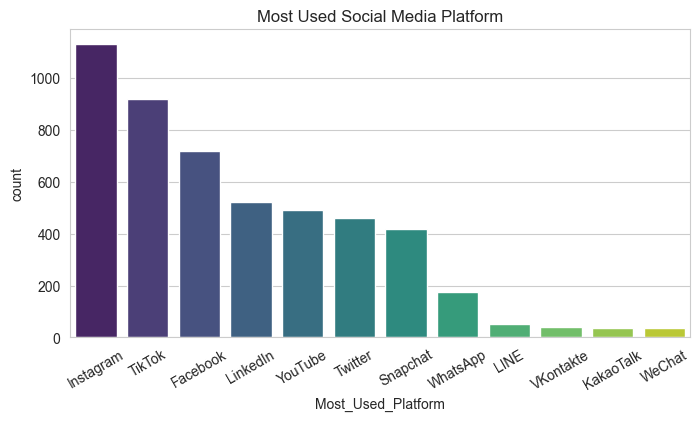

In [13]:
plt.figure(figsize=(8, 4))
platform_order = df["Most_Used_Platform"].value_counts().index
sns.countplot(x="Most_Used_Platform", data=df, order=platform_order, palette="viridis")
plt.title("Most Used Social Media Platform")
plt.xticks(rotation=30)
plt.show()

### 6.7 Outlier Check (IQR Method)

In [14]:
def count_outliers_iqr(data):
    numeric_data = data.select_dtypes(include="number")
    q1 = numeric_data.quantile(0.25)
    q3 = numeric_data.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (numeric_data < lower_bound) | (numeric_data > upper_bound)
    return outlier_mask.sum()


count_outliers_iqr(df)

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64

### 6.8 Fixing Unrealistic Values

In [15]:
df["Physical_Activity_Hours"] = df["Physical_Activity_Hours"].clip(lower=0)

## 7. Feature Engineering

`Country` has many unique values, most with very few rows. We group the less frequent countries into a single `Other` category so the model can learn meaningful patterns instead of noise.

In [16]:
def group_rare_countries(data, top_n=10):
    top_countries = data["Country"].value_counts().index[:top_n].tolist()
    data["Grouped_Country"] = data["Country"].apply(lambda c: c if c in top_countries else "Other")
    return data


df = group_rare_countries(df, top_n=10)
df["Grouped_Country"].value_counts()

Grouped_Country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

## 8. Separate Numerical and Categorical Columns

In [17]:
skewed_col = ["Study_Hours"]

numeric_cols = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks",
                "Physical_Activity_Hours", "Sleep_Hours_Per_Night"]

ordinal_col = ["Stress_Level"]

categorical_cols = ["Gender", "Academic_Level", "Most_Used_Platform",
                     "Purpose_Of_Use", "Grouped_Country"]

feature_cols = skewed_col + numeric_cols + ordinal_col + categorical_cols

X = df[feature_cols]
y = df[TARGET]

print(f"Total features used: {len(feature_cols)}")

Total features used: 12


## 9. Preprocessing Pipeline

- `Study_Hours` is right-skewed, so we log-transform it before scaling.
- Other numeric columns are standardized with `StandardScaler`.
- `Stress_Level` has a natural order, so it is ordinal-encoded.
- Remaining categorical columns are one-hot encoded.

In [18]:
skewed_pipeline = Pipeline(steps=[
    ("log_transform", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scale", StandardScaler())
])

numeric_pipeline = Pipeline(steps=[
    ("scale", StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    ("encode", OrdinalEncoder(categories=[["Low", "Medium", "High", "Very High"]]))
])

categorical_pipeline = Pipeline(steps=[
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("skewed", skewed_pipeline, skewed_col),
    ("numeric", numeric_pipeline, numeric_cols),
    ("ordinal", ordinal_pipeline, ordinal_col),
    ("categorical", categorical_pipeline, categorical_cols)
])

## 10. Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 3998
Testing samples: 1000


## 11. Model Building

### 11.1 Helper Function for Evaluation

In [20]:
def evaluate_model(model_name, pipeline, X_train, y_train, X_test, y_test):
    train_preds = pipeline.predict(X_train)
    test_preds = pipeline.predict(X_test)

    metrics = {
        "Model": model_name,
        "Train R2": r2_score(y_train, train_preds),
        "Test R2": r2_score(y_test, test_preds),
        "MAE": mean_absolute_error(y_test, test_preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, test_preds))
    }

    print(f"{model_name} -> R2: {metrics['Test R2']:.4f} | MAE: {metrics['MAE']:.4f} | RMSE: {metrics['RMSE']:.4f}")
    return metrics

### 11.2 Linear Regression (Baseline)

In [21]:
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_metrics = evaluate_model("Linear Regression", lr_pipeline, X_train, y_train, X_test, y_test)

Linear Regression -> R2: 0.7428 | MAE: 0.5339 | RMSE: 0.6776


### 11.3 Random Forest Regressor

In [22]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_metrics = evaluate_model("Random Forest (default)", rf_pipeline, X_train, y_train, X_test, y_test)

Random Forest (default) -> R2: 0.8902 | MAE: 0.3267 | RMSE: 0.4428


## 12. Hyperparameter Tuning (RandomizedSearchCV)

In [23]:
param_grid = {
    "regressor__n_estimators": [100, 200, 300, 400],
    "regressor__max_depth": [5, 10, 15, 20],
    "regressor__min_samples_split": [2, 5, 10, 15],
    "regressor__min_samples_leaf": [1, 2, 4, 8]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print("Best parameters found:")
random_search.best_params_

Best parameters found:


{'regressor__n_estimators': 100,
 'regressor__min_samples_split': 10,
 'regressor__min_samples_leaf': 1,
 'regressor__max_depth': 15}

In [24]:
rf_tuned_pipeline = random_search.best_estimator_
rf_tuned_metrics = evaluate_model("Random Forest (tuned)", rf_tuned_pipeline, X_train, y_train, X_test, y_test)

Random Forest (tuned) -> R2: 0.8717 | MAE: 0.3623 | RMSE: 0.4786


## 13. Cross Validation

In [25]:
def cross_validate_pipeline(name, pipeline, X, y, cv=5):
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring="r2")
    print(f"{name} -> CV R2 Mean: {scores.mean():.4f} | CV R2 Std: {scores.std():.4f}")
    return scores.mean()


lr_cv_score = cross_validate_pipeline("Linear Regression", lr_pipeline, X, y)
rf_cv_score = cross_validate_pipeline("Random Forest (tuned)", rf_tuned_pipeline, X, y)

Linear Regression -> CV R2 Mean: 0.7211 | CV R2 Std: 0.0223
Random Forest (tuned) -> CV R2 Mean: 0.8622 | CV R2 Std: 0.0146


## 14. Model Comparison and Automatic Selection

In [26]:
results_df = pd.DataFrame([lr_metrics, rf_metrics, rf_tuned_metrics])
results_df["CV R2"] = [lr_cv_score, rf_cv_score, rf_cv_score]
results_df

,Model,Train R2,Test R2,MAE,RMSE,CV R2
0,Linear Regression,0.725567,0.742813,0.533889,0.677593,0.721135
1,Random Forest (default),0.982709,0.890151,0.326722,0.442835,0.862228
2,Random Forest (tuned),0.942705,0.871672,0.362288,0.478636,0.862228


In [27]:
candidate_models = {
    "Linear Regression": (lr_pipeline, lr_metrics["Test R2"]),
    "Random Forest (default)": (rf_pipeline, rf_metrics["Test R2"]),
    "Random Forest (tuned)": (rf_tuned_pipeline, rf_tuned_metrics["Test R2"])
}

best_model_name = max(candidate_models, key=lambda name: candidate_models[name][1])
best_pipeline = candidate_models[best_model_name][0]

print(f"Best performing model: {best_model_name}")

Best performing model: Random Forest (default)


## 15. Feature Importance

C:\Users\Malik Umair\AppData\Local\Temp\ipykernel_16220\2480245650.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance_df, palette="mako")


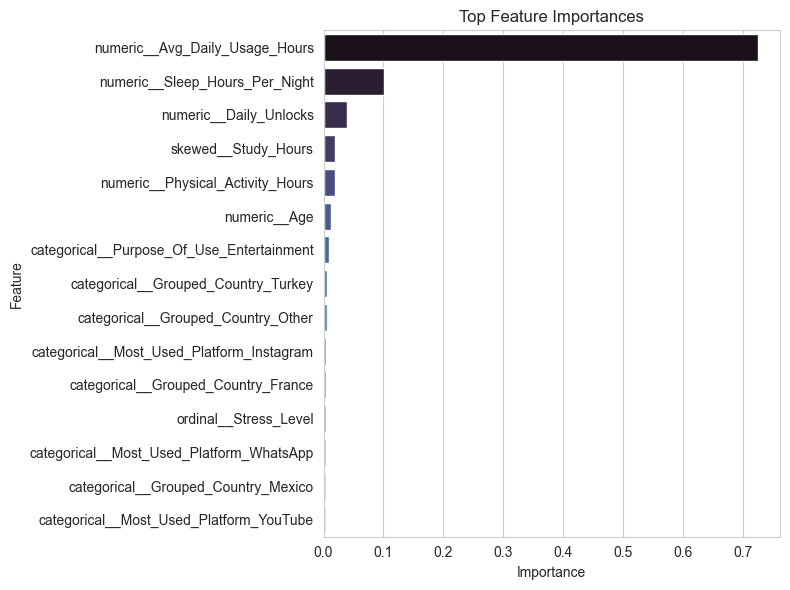

,Feature,Importance
2,numeric__Avg_Daily_Usage_Hours,0.725855
5,numeric__Sleep_Hours_Per_Night,0.101531
3,numeric__Daily_Unlocks,0.039828
0,skewed__Study_Hours,0.019024
4,numeric__Physical_Activity_Hours,0.018893
1,numeric__Age,0.012341
25,categorical__Purpose_Of_Use_Entertainment,0.008939
35,categorical__Grouped_Country_Turkey,0.005475
34,categorical__Grouped_Country_Other,0.005050
13,categorical__Most_Used_Platform_Instagram,0.004815


In [28]:
def plot_feature_importance(pipeline, top_n=15):
    model = pipeline.named_steps["regressor"]
    feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False).head(top_n)

    plt.figure(figsize=(8, 6))
    sns.barplot(x="Importance", y="Feature", data=importance_df, palette="mako")
    plt.title("Top Feature Importances")
    plt.tight_layout()
    plt.show()

    return importance_df


importance_table = plot_feature_importance(rf_tuned_pipeline)
importance_table

## 16. Risk Level Classification

Mental Health Score ranges from 0 to 10. We map the predicted score into four risk categories.

In [29]:
def get_risk_level(score):
    if score >= 7:
        return "Healthy"
    elif score >= 5:
        return "Mild Concern"
    elif score >= 3.5:
        return "Moderate Risk"
    else:
        return "High Risk"


df["Risk_Level"] = df[TARGET].apply(get_risk_level)
df["Risk_Level"].value_counts()

Risk_Level
Mild Concern     2558
Healthy          1587
Moderate Risk     853
Name: count, dtype: int64

## 17. Recommendation Engine

In [30]:
def generate_recommendations(user_input):
    recommendations = []

    if user_input["Sleep_Hours_Per_Night"] < 7:
        recommendations.append("Aim for 7-8 hours of sleep per night.")

    if user_input["Stress_Level"] in ["High", "Very High"]:
        recommendations.append("Practice stress management techniques such as meditation or journaling.")

    if user_input["Avg_Daily_Usage_Hours"] > 5:
        recommendations.append("Reduce daily social media screen time.")

    if user_input["Physical_Activity_Hours"] < 1.5:
        recommendations.append("Add at least 30 minutes of physical activity to your daily routine.")

    if user_input["Daily_Unlocks"] > 150:
        recommendations.append("Reduce unnecessary phone checking throughout the day.")

    if not recommendations:
        recommendations.append("Your current lifestyle habits look well balanced. Keep it up!")

    return recommendations

## 18. Prediction for Sample Users

In [31]:
sample_users = pd.DataFrame([
    {
        "Study_Hours": 3.0, "Age": 20, "Avg_Daily_Usage_Hours": 6.5, "Daily_Unlocks": 180,
        "Physical_Activity_Hours": 1.0, "Sleep_Hours_Per_Night": 5.5, "Stress_Level": "High",
        "Gender": "Male", "Academic_Level": "Undergraduate", "Most_Used_Platform": "Instagram",
        "Purpose_Of_Use": "Entertainment", "Grouped_Country": "Other"
    },
    {
        "Study_Hours": 6.0, "Age": 23, "Avg_Daily_Usage_Hours": 2.0, "Daily_Unlocks": 80,
        "Physical_Activity_Hours": 3.0, "Sleep_Hours_Per_Night": 8.0, "Stress_Level": "Low",
        "Gender": "Female", "Academic_Level": "Graduate", "Most_Used_Platform": "LinkedIn",
        "Purpose_Of_Use": "Education", "Grouped_Country": "Other"
    }
])

sample_predictions = best_pipeline.predict(sample_users)
sample_predictions

array([5.074, 7.919])

### 18.1 Professional Prediction Report

In [32]:
def clean_feature_name(feature_name):
    name = feature_name.split("__", 1)[-1]
    return name.replace("_", " ")


def generate_report(user_input, pipeline, importance_table, top_n_factors=3):
    user_df = pd.DataFrame([user_input])
    predicted_score = pipeline.predict(user_df)[0]
    risk_level = get_risk_level(predicted_score)
    recommendations = generate_recommendations(user_input)
    top_factors = [clean_feature_name(f) for f in importance_table["Feature"].head(top_n_factors)]

    print("=" * 50)
    print("MENTAL HEALTH PREDICTION REPORT")
    print("=" * 50)
    print(f"Mental Health Score : {predicted_score:.2f} / 10")
    print(f"Risk Level          : {risk_level}")
    print(f"Top Factors         : {', '.join(top_factors)}")
    print("Personalized Recommendations:")
    for i, rec in enumerate(recommendations, start=1):
        print(f"  {i}. {rec}")
    print("-" * 50)
    print(f"Overall Lifestyle Summary: Based on the provided habits, this user "
          f"falls under the '{risk_level}' category with a predicted score of "
          f"{predicted_score:.2f}.")
    print("=" * 50)

    return {
        "Mental_Health_Score": predicted_score,
        "Risk_Level": risk_level,
        "Top_Factors": top_factors,
        "Recommendations": recommendations
    }


sample_user = sample_users.iloc[0].to_dict()
report = generate_report(sample_user, best_pipeline, importance_table)

MENTAL HEALTH PREDICTION REPORT
Mental Health Score : 5.07 / 10
Risk Level          : Mild Concern
Top Factors         : Avg Daily Usage Hours, Sleep Hours Per Night, Daily Unlocks
Personalized Recommendations:
  1. Aim for 7-8 hours of sleep per night.
  2. Practice stress management techniques such as meditation or journaling.
  3. Reduce daily social media screen time.
  4. Add at least 30 minutes of physical activity to your daily routine.
  5. Reduce unnecessary phone checking throughout the day.
--------------------------------------------------
Overall Lifestyle Summary: Based on the provided habits, this user falls under the 'Mild Concern' category with a predicted score of 5.07.


## 19. Save the Final Pipeline

In [33]:
joblib.dump(best_pipeline, "model.pkl")
print("Model saved as model.pkl")

Model saved as model.pkl


## 20. Load the Saved Model and Predict on New Data

In [34]:
loaded_pipeline = joblib.load("model.pkl")

new_user = {
    "Study_Hours": 4.5, "Age": 21, "Avg_Daily_Usage_Hours": 4.0, "Daily_Unlocks": 120,
    "Physical_Activity_Hours": 2.0, "Sleep_Hours_Per_Night": 6.5, "Stress_Level": "Medium",
    "Gender": "Male", "Academic_Level": "Undergraduate", "Most_Used_Platform": "Facebook",
    "Purpose_Of_Use": "Networking", "Grouped_Country": "Other"
}

final_report = generate_report(new_user, loaded_pipeline, importance_table)

MENTAL HEALTH PREDICTION REPORT
Mental Health Score : 7.08 / 10
Risk Level          : Healthy
Top Factors         : Avg Daily Usage Hours, Sleep Hours Per Night, Daily Unlocks
Personalized Recommendations:
  1. Aim for 7-8 hours of sleep per night.
--------------------------------------------------
Overall Lifestyle Summary: Based on the provided habits, this user falls under the 'Healthy' category with a predicted score of 7.08.


## Conclusion

This project builds a complete machine learning pipeline that predicts a student's Mental Health Score from lifestyle and social media usage data. The Random Forest Regressor, after hyperparameter tuning, was selected as the final model based on its superior R² score compared to Linear Regression. The final pipeline (preprocessing + model) is saved as `model.pkl` and can be reused directly on new, unseen data through the recommendation and reporting functions built above.